## TECH CHALLENGE - FASE 3

## Exploração do Dataset MedQuAD

Este notebook tem como objetivo explorar a estrutura do dataset MedQuAD, entender o formato dos arquivos XML e preparar os dados para uso no
assistente médico que foi requisitado para fase 3.

Nesta etapa, serão realizadas as seguintes atividades:

- localização dos arquivos do dataset no projeto
- inspeção inicial da estrutura dos arquivos XML
- identificação dos campos de pergunta e resposta
- extração estruturada dos dados
- preparação de um arquivo processado para uso posterior em RAG e fine-tuning
- demontrações dos testes do assistente médico
- demonstração da integração do Langgraph com o assistente médico

O foco inicial será a coleção `1_CancerGov_QA`, por estar mais alinhada
ao tema já trabalhado nas fases anteriores do projeto.

In [7]:
from pathlib import Path
import xml.etree.ElementTree as ET
import json
import pandas as pd

Import das bibliotecas necessárias

In [8]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.rag.documents_loader import load_medquad_documents
from src.rag.vector_store import build_vector_store, save_vector_store
from src.rag.retriever import get_retriever
from src.llm.ollama_client import get_llm
from src.assistant.medical_assistant import answer_medical_question
from src.security.guardrails import evaluate_question_risk, build_guardrail_response
from src.llm.fine_tuning import (
    prepare_finetuning_dataset,
    split_finetuning_dataset,
    save_finetuning_dataset,
    run_medical_finetuning,
)


Import das funções python criadas no projeto

## 1. Definição do caminho do dataset

Nesta etapa, será definido o caminho da pasta onde foi armazenado o
dataset MedQuAD dentro do projeto.

Inicialmente, a exploração será feita na coleção `1_CancerGov_QA`,
pois ela contém perguntas e respostas relacionadas ao domínio oncológico,
o que torna essa base mais aderente ao contexto do projeto.

In [9]:
base_path = Path("../data/medical_qa/raw/MedQuAD/1_CancerGov_QA")
files = list(base_path.glob("*.xml"))

print(f"Total de arquivos XML encontrados: {len(files)}")
print("\nPrimeiros 8 arquivos:")
for f in files[:8]:
    print(f.name)

Total de arquivos XML encontrados: 116

Primeiros 8 arquivos:
0000001_1.xml
0000001_2.xml
0000001_3.xml
0000001_4.xml
0000001_5.xml
0000001_6.xml
0000001_7.xml
0000003_1.xml


## 2. Inspeção inicial de um arquivo XML

Um arquivo será selecionado para inspeção manual.
Essa etapa é importante para compreender a estrutura bruta do XML e verificar como as informações estão organizadas internamente.

In [10]:
sample_file = files[0]
sample_file

WindowsPath('../data/medical_qa/raw/MedQuAD/1_CancerGov_QA/0000001_1.xml')

In [11]:
with open(sample_file, "r", encoding="utf-8") as f: content = f.read()

print(content[:2000])

<?xml version="1.0" encoding="UTF-8"?>
<Document id="0000001_1" source="CancerGov" url="https://www.cancer.gov/types/leukemia/patient/adult-all-treatment-pdq">
<Focus>Adult Acute Lymphoblastic Leukemia</Focus>
<FocusAnnotations>
	<UMLS>
		<CUIs>
			<CUI>C0751606</CUI>
		</CUIs>
		<SemanticTypes>
			<SemanticType>T191</SemanticType>
		</SemanticTypes>
		<SemanticGroup>Disorders</SemanticGroup>
	</UMLS>
</FocusAnnotations>
<QAPairs>
	<QAPair pid="1">
			<Question qid="0000001_1-1" qtype="information">What is (are) Adult Acute Lymphoblastic Leukemia ?</Question>
			<Answer>Key Points
                    - Adult acute lymphoblastic leukemia (ALL) is a type of cancer in which the bone marrow makes too many lymphocytes (a type of white blood cell).    - Leukemia may affect red blood cells, white blood cells, and platelets.    - Previous chemotherapy and exposure to radiation may increase the risk of developing ALL.    - Signs and symptoms of adult ALL include fever, feeling tired, and easy b

## 3. Leitura da estrutura XML

Após observar o conteúdo bruto do arquivo, será feito o parsing do XML com a biblioteca `xml.etree.ElementTree`.

O objetivo desta etapa é identificar a tag raiz e compreender a organização hierárquica dos elementos presentes no arquivo.

A partir disso será possível localizar onde estão as informações mecessárias para responder os futuros questionamentos feitos para o agente.

In [12]:
tree = ET.parse(sample_file)
root = tree.getroot()

print("Tag raiz:", root.tag)
print("\nFilhos imediatos da raiz:")
for child in root:
    print(child.tag)

Tag raiz: Document

Filhos imediatos da raiz:
Focus
FocusAnnotations
QAPairs


## 4. Identificação das tags existentes

Nesta etapa, serão listadas as tags encontradas no arquivo XML para
identificar onde estão armazenadas as perguntas e as respostas.

Esse passo é importante porque permite construir um parser adequado
para a estrutura específica do MedQuAD.

In [13]:
tags = set()

for elem in root.iter():
    tags.add(elem.tag)

print("Tags encontradas no XML:")
for tag in sorted(tags):
    print(tag)

Tags encontradas no XML:
Answer
CUI
CUIs
Document
Focus
FocusAnnotations
QAPair
QAPairs
Question
SemanticGroup
SemanticType
SemanticTypes
UMLS


## 5. Inspeção dos elementos textuais

Agora serão exibidos os elementos do XML que possuem conteúdo textual.
Essa inspeção ajuda a localizar os campos que efetivamente armazenam
as perguntas e respostas do dataset.

In [14]:
for elem in root.iter():
    if elem.text and elem.text.strip():
        print(f"{elem.tag} => {elem.text.strip()[:300]}")
        print("-" * 80)

Focus => Adult Acute Lymphoblastic Leukemia
--------------------------------------------------------------------------------
CUI => C0751606
--------------------------------------------------------------------------------
SemanticType => T191
--------------------------------------------------------------------------------
SemanticGroup => Disorders
--------------------------------------------------------------------------------
Question => What is (are) Adult Acute Lymphoblastic Leukemia ?
--------------------------------------------------------------------------------
Answer => Key Points
                    - Adult acute lymphoblastic leukemia (ALL) is a type of cancer in which the bone marrow makes too many lymphocytes (a type of white blood cell).    - Leukemia may affect red blood cells, white blood cells, and platelets.    - Previous chemotherapy and exposure to radia
--------------------------------------------------------------------------------
Question => What are the symptom

## 6. Criação da função de extração de pares pergunta-resposta

Com base na estrutura observada no XML, será criada uma função para extrair os pares de pergunta e resposta de cada arquivo.

Essa função permitirá automatizar a leitura de múltiplos arquivos da coleção selecionada.

In [15]:
def parse_medquad_xml(sample_file):
    tree = ET.parse(sample_file)
    root = tree.getroot()

    records = []
    file_name = Path(sample_file).name

    for idx, qa_pair in enumerate(root.findall(".//QAPair")):
        question = qa_pair.findtext("Question")
        answer = qa_pair.findtext("Answer")

        if question and answer:
            records.append({
                "id": f"{file_name}_{idx}",
                "source_file": file_name,
                "collection": "CancerGov",
                "question": question.strip(),
                "answer": answer.strip()
            })

    return records

## 7. Teste da função em um arquivo de exemplo

Nesta etapa, a função criada será aplicada a um único arquivo XML, com o objetivo de validar se a extração dos pares pergunta-resposta está ocorrendo corretamente.

In [16]:
records = parse_medquad_xml(sample_file)

print(f"Total de pares extraídos do arquivo de exemplo: {len(records)}")
records[:2]

Total de pares extraídos do arquivo de exemplo: 7


[{'id': '0000001_1.xml_0',
  'source_file': '0000001_1.xml',
  'collection': 'CancerGov',
  'question': 'What is (are) Adult Acute Lymphoblastic Leukemia ?',
  'answer': 'Key Points\n                    - Adult acute lymphoblastic leukemia (ALL) is a type of cancer in which the bone marrow makes too many lymphocytes (a type of white blood cell).    - Leukemia may affect red blood cells, white blood cells, and platelets.    - Previous chemotherapy and exposure to radiation may increase the risk of developing ALL.    - Signs and symptoms of adult ALL include fever, feeling tired, and easy bruising or bleeding.     - Tests that examine the blood and bone marrow are used to detect (find) and diagnose adult ALL.    - Certain factors affect prognosis (chance of recovery) and treatment options.\n                \n                \n                    Adult acute lymphoblastic leukemia (ALL) is a type of cancer in which the bone marrow makes too many lymphocytes (a type of white blood cell).\n

## 8. Extração dos dados de todos os arquivos da coleção

Após validar a função em um arquivo de exemplo, será feita a extração dos dados de todos os arquivos XML da coleção `1_CancerGov_QA`.

Ao final, será gerada uma lista consolidada com todos os pares pergunta-resposta encontrados.

In [17]:
all_records = []

for file_path in files:
    try:
        extracted = parse_medquad_xml(file_path)
        all_records.extend(extracted)
    except Exception as e:
        print(f"Erro ao processar {file_path.name}: {e}")

print(f"Total de registros extraídos: {len(all_records)}")

Total de registros extraídos: 729


## 9. Conversão para DataFrame

Nesta etapa, os registros extraídos serão convertidos para um DataFrame,
facilitando a visualização, inspeção e futuras etapas de pré-processamento.

In [18]:
df_medquad = pd.DataFrame(all_records)

print(df_medquad.shape)
df_medquad.head()

(729, 5)


,id,source_file,collection,question,answer
0,0000001_1.xml_0,0000001_1.xml,CancerGov,What is (are) Adult Acute Lymphoblastic Leukem...,Key Points\n - Adult acute ...
1,0000001_1.xml_1,0000001_1.xml,CancerGov,What are the symptoms of Adult Acute Lymphobla...,"Signs and symptoms of adult ALL include fever,..."
2,0000001_1.xml_2,0000001_1.xml,CancerGov,How to diagnose Adult Acute Lymphoblastic Leuk...,Tests that examine the blood and bone marrow a...
3,0000001_1.xml_3,0000001_1.xml,CancerGov,What is the outlook for Adult Acute Lymphoblas...,Certain factors affect prognosis (chance of re...
4,0000001_1.xml_4,0000001_1.xml,CancerGov,Who is at risk for Adult Acute Lymphoblastic L...,Previous chemotherapy and exposure to radiatio...


## 10. Verificação de valores ausentes e duplicados

Antes de salvar o dataset processado, é importante realizar uma verificação
simples de qualidade dos dados, observando a presença de valores nulos
e registros duplicados.

In [19]:
print("Valores nulos:")
print(df_medquad.isnull().sum())

print("\nRegistros duplicados:")
print(df_medquad.duplicated().sum())

Valores nulos:
id             0
source_file    0
collection     0
question       0
answer         0
dtype: int64

Registros duplicados:
0


Conforme o que foi gerado, é possível notar que não há valores nulos ou duplicados.
Desta forma, podemos dar seguimento ao salvamento do dataset.

## 11. Salvamento do dataset processado

Por fim, o conjunto de dados tratado será salvo na pasta `processed`, permitindo seu reaproveitamento nas próximas fases do pipeline, como construção da base vetorial, RAG e fine-tuning.

In [20]:
json_path = "../data/medical_qa/processed/medquad_cancergov_qa.json"
documents = load_medquad_documents(json_path)

print("Total de documentos:", len(documents))
documents[0]

Total de documentos: 812


Document(metadata={'id': '0000001_1.xml_0', 'source_file': '0000001_1.xml', 'collection': 'CancerGov', 'source': 'MedQuAD'}, page_content='Question: What is (are) Adult Acute Lymphoblastic Leukemia ?\nAnswer: Key Points\n                    - Adult acute lymphoblastic leukemia (ALL) is a type of cancer in which the bone marrow makes too many lymphocytes (a type of white blood cell).    - Leukemia may affect red blood cells, white blood cells, and platelets.    - Previous chemotherapy and exposure to radiation may increase the risk of developing ALL.    - Signs and symptoms of adult ALL include fever, feeling tired, and easy bruising or bleeding.     - Tests that examine the blood and bone marrow are used to detect (find) and diagnose adult ALL.    - Certain factors affect prognosis (chance of recovery) and treatment options.\n                \n                \n                    Adult acute lymphoblastic leukemia (ALL) is a type of cancer in which the bone marrow makes too many lymph

## 12. Preparação do dataset para fine-tuning

Nesta etapa, o dataset estruturado `df_medquad` passa a ser reutilizado não apenas para a arquitetura RAG, mas também para um processo de fine-tuning supervisionado do modelo base.

A ideia é converter os pares de pergunta e resposta do MedQuAD para um formato de instrução, permitindo adaptar o modelo para responder perguntas médicas com maior consistência, clareza e aderência ao domínio.

### Objetivo desta etapa
- Reaproveitar o dataset já processado
- Criar exemplos no formato instrução > pergunta > resposta
- Preparar os dados para treinamento supervisionado (SFT)
- Manter o pipeline RAG já existente sem alterações estruturais

### Observação importante
O fine-tuning **não substitui** o RAG neste projeto.  
A proposta é combinar as duas abordagens:

- **Fine-tuning**: melhora o comportamento geral do modelo
- **RAG**: fornece contexto recuperado e reduz alucinações

Assim, o sistema continua baseado em recuperação de contexto, mas passa a utilizar um modelo mais adaptado ao domínio médico.

In [21]:
finetune_df = prepare_finetuning_dataset(df_medquad)
train_df, val_df = split_finetuning_dataset(finetune_df, test_size=0.1, random_state=42)

finetune_path = "../data/medical_qa/processed/medquad_cancergov_qa_finetuning.jsonl"
save_finetuning_dataset(finetune_df, finetune_path)

print("Dataset para fine-tuning salvo em:", finetune_path)
print("Total de exemplos:", len(finetune_df))
print("Treino:", len(train_df))
print("Validação:", len(val_df))
finetune_df.head(2)


Dataset para fine-tuning salvo em: ../data/medical_qa/processed/medquad_cancergov_qa_finetuning.jsonl
Total de exemplos: 729
Treino: 656
Validação: 73


,question,answer,text
0,What is (are) Adult Acute Lymphoblastic Leukem...,Key Points\n - Adult acute ...,### Instrução:\nResponda à pergunta médica de ...
1,What are the symptoms of Adult Acute Lymphobla...,"Signs and symptoms of adult ALL include fever,...",### Instrução:\nResponda à pergunta médica de ...


## Ambiente de Treinamento

O fine-tuning do modelo foi realizado em ambiente **Kaggle**, escolhido por disponibilizar acesso a GPU compatível com o treinamento de modelos de linguagem em um contexto de recursos computacionais limitados.

Inicialmente, a execução havia sido planejada no **Google Colab**, mas devido às limitações de uso da GPU durante o desenvolvimento do projeto, foi necessária a migração do pipeline para o Kaggle.

Nesse novo ambiente, foi possível dar continuidade ao processo de treinamento utilizando técnicas como **quantização em 4 bits** e **LoRA (Low-Rank Adaptation)**, reduzindo o custo computacional e tornando o ajuste do modelo mais viável.

Após o treinamento, os artefatos gerados são utilizados no próprio notebook para validação, análise dos resultados e testes de inferência.

In [22]:
finetune_df.head()
finetune_df.shape
finetune_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 729 entries, 0 to 728
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   question  729 non-null    object
 1   answer    729 non-null    object
 2   text      729 non-null    object
dtypes: object(3)
memory usage: 17.2+ KB


In [23]:
finetune_df["question_len"] = finetune_df["question"].str.len()
finetune_df["answer_len"] = finetune_df["answer"].str.len()

finetune_df[["question_len", "answer_len"]].describe()

,question_len,answer_len
count,729.000000,729.000000
mean,53.879287,3881.226337
std,17.699622,4905.466486
min,24.000000,49.000000
25%,41.000000,782.000000
50%,51.000000,1882.000000
75%,65.000000,4355.000000
max,120.000000,29046.000000


## Análise do dataset:
O dataset possui 729 exemplos com perguntas relativamente curtas (média ~54 caracteres) e respostas muito longas e variáveis (média ~3881 caracteres, podendo chegar a ~29k).

## Observação importante:
Existe alta variabilidade no tamanho das respostas (desvio padrão elevado), o que pode causar truncamento durante o treinamento (max_seq_length=256) e impactar negativamente o aprendizado do modelo. O modelo pode não estar vendo respostas completas, o que contribui para alucinações.

## Sugestão:
Avaliar truncamento ou limitar o tamanho das respostas (ex: cortar respostas muito longas) para tornar o treinamento mais consistente.

In [24]:
finetune_df.sample(5)

,question,answer,text,question_len,answer_len
182,What is (are) Childhood Brain Stem Glioma ?,Key Points \n - Childhood b...,### Instrução:\nResponda à pergunta médica de ...,43,3347
16,Who is at risk for Chronic Lymphocytic Leukemi...,Older age can affect the risk of developing ch...,### Instrução:\nResponda à pergunta médica de ...,50,562
420,What is the outlook for Testicular Cancer ?,Testicular cancer can usually be cured. Althou...,### Instrução:\nResponda à pergunta médica de ...,43,379
270,How to diagnose Gastrointestinal Carcinoid Tum...,Imaging studies and tests that examine the blo...,### Instrução:\nResponda à pergunta médica de ...,51,4828
591,How to diagnose Merkel Cell Carcinoma ?,Tests and procedures that examine the skin are...,### Instrução:\nResponda à pergunta médica de ...,39,781


In [25]:
import pandas as pd

results = pd.DataFrame({
    "epoch": [1,2],
    "train_loss": [0.484647, 0.280510],
    "val_loss": [0.372633, 0.313341]
})

results

,epoch,train_loss,val_loss
0,1,0.484647,0.372633
1,2,0.280510,0.313341


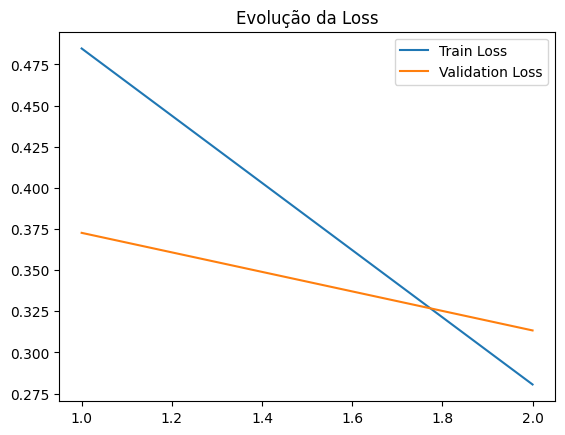

In [26]:
import matplotlib.pyplot as plt

plt.plot(results["epoch"], results["train_loss"], label="Train Loss")
plt.plot(results["epoch"], results["val_loss"], label="Validation Loss")
plt.legend()
plt.title("Evolução da Loss")
plt.show()

## Interpretação da evolução da loss

O gráfico apresenta redução consistente tanto da training loss quanto da validation loss ao longo das épocas, indicando que o modelo está aprendendo padrões relevantes a partir dos dados.

- A training loss apresenta uma queda mais acentuada, evidenciando forte ajuste do modelo ao conjunto de treino.
- A validation loss também diminui, porém de forma mais gradual, sugerindo melhora na capacidade de generalização.

Podemos identificar que, na última época, a training loss torna-se inferior à validation loss, o que é esperado durante o processo de treinamento e pode indicar início de especialização do modelo nos dados de treino.

Apesar dessa diferença entre as curvas, não há evidências claras de overfitting neste intervalo analisado, uma vez que a validation loss continua em queda.

De forma geral, os resultados indicam um treinamento estável e eficiente, com bom equilíbrio entre aprendizado e generalização.

## 13. Visualização de exemplos finais

Para concluir esta etapa, serão exibidos alguns exemplos do dataset processado, permitindo validar visualmente o resultado da extração.

In [27]:
for i, row in df_medquad.head(3).iterrows():
    print(f"Registro {i+1}")
    print(f"Arquivo de origem: {row['source_file']}")
    print(f"Pergunta: {row['question']}")
    print(f"Resposta: {row['answer'][:500]}")
    print("=" * 100)

Registro 1
Arquivo de origem: 0000001_1.xml
Pergunta: What is (are) Adult Acute Lymphoblastic Leukemia ?
Resposta: Key Points
                    - Adult acute lymphoblastic leukemia (ALL) is a type of cancer in which the bone marrow makes too many lymphocytes (a type of white blood cell).    - Leukemia may affect red blood cells, white blood cells, and platelets.    - Previous chemotherapy and exposure to radiation may increase the risk of developing ALL.    - Signs and symptoms of adult ALL include fever, feeling tired, and easy bruising or bleeding.     - Tests that examine the blood and bone marrow are u
Registro 2
Arquivo de origem: 0000001_1.xml
Pergunta: What are the symptoms of Adult Acute Lymphoblastic Leukemia ?
Resposta: Signs and symptoms of adult ALL include fever, feeling tired, and easy bruising or bleeding. The early signs and symptoms of ALL may be like the flu or other common diseases. Check with your doctor if you have any of the following:         - Weakness or feel

## 14. Preparação de documentos para RAG (Retrieval-Augmented Generation)

Nesta etapa os pares pergunta-resposta serão convertidos em documentos que poderão ser indexados em uma base vetorial.


In [28]:
from langchain_core.documents import Document

documents = []

for _, row in df_medquad.iterrows():

    text = f"""
Question: {row['question']}
Answer: {row['answer']}
"""

    metadata = {
        "source_file": row["source_file"],
        "collection": row["collection"],
        "id": row["id"]
    }

    documents.append(
        Document(
            page_content=text,
            metadata=metadata
        )
    )

print("Total de documentos criados:", len(documents))
documents[0]

Total de documentos criados: 729


Document(metadata={'source_file': '0000001_1.xml', 'collection': 'CancerGov', 'id': '0000001_1.xml_0'}, page_content='\nQuestion: What is (are) Adult Acute Lymphoblastic Leukemia ?\nAnswer: Key Points\n                    - Adult acute lymphoblastic leukemia (ALL) is a type of cancer in which the bone marrow makes too many lymphocytes (a type of white blood cell).    - Leukemia may affect red blood cells, white blood cells, and platelets.    - Previous chemotherapy and exposure to radiation may increase the risk of developing ALL.    - Signs and symptoms of adult ALL include fever, feeling tired, and easy bruising or bleeding.     - Tests that examine the blood and bone marrow are used to detect (find) and diagnose adult ALL.    - Certain factors affect prognosis (chance of recovery) and treatment options.\n                \n                \n                    Adult acute lymphoblastic leukemia (ALL) is a type of cancer in which the bone marrow makes too many lymphocytes (a type of w

Os pares pergunta-resposta serão convertidos em documentos que serão indexados em uma base vetorial.

Foram criadas 729 unidades de conhecimento para consulta na base vetorial.

Os dados foram transformados em um texto único, por conta da forma como os embeddings funcionam com textos contínuos.

O objeto Document é criado seguindo o padrão do LangChain.

In [29]:
print(f"Total de documents: {len(documents)}\n")

for i, doc in enumerate(documents[:10], 1):
    print(f"--- Documento {i} ---")
    print("ID:", doc.metadata.get("id"))
    print("Arquivo:", doc.metadata.get("source_file"))
    print("Coleção:", doc.metadata.get("collection"))
    print("Conteúdo:")
    print(doc.page_content[:500])
    print("\n")

Total de documents: 729

--- Documento 1 ---
ID: 0000001_1.xml_0
Arquivo: 0000001_1.xml
Coleção: CancerGov
Conteúdo:

Question: What is (are) Adult Acute Lymphoblastic Leukemia ?
Answer: Key Points
                    - Adult acute lymphoblastic leukemia (ALL) is a type of cancer in which the bone marrow makes too many lymphocytes (a type of white blood cell).    - Leukemia may affect red blood cells, white blood cells, and platelets.    - Previous chemotherapy and exposure to radiation may increase the risk of developing ALL.    - Signs and symptoms of adult ALL include fever, feeling tired, and easy bruising


--- Documento 2 ---
ID: 0000001_1.xml_1
Arquivo: 0000001_1.xml
Coleção: CancerGov
Conteúdo:

Question: What are the symptoms of Adult Acute Lymphoblastic Leukemia ?
Answer: Signs and symptoms of adult ALL include fever, feeling tired, and easy bruising or bleeding. The early signs and symptoms of ALL may be like the flu or other common diseases. Check with your doctor if you ha

In [30]:
source_files = [doc.metadata.get("source_file") for doc in documents]
unique_files = set(source_files)

print("Total de documentos:", len(documents))
print("Total de arquivos únicos:", len(unique_files))
print("\nAlguns arquivos únicos:")
print(list(unique_files)[:20])

Total de documentos: 729
Total de arquivos únicos: 116

Alguns arquivos únicos:
['0000032_4.xml', '0000001_6.xml', '0000004_4.xml', '0000028_2.xml', '0000032_1.xml', '0000019_2.xml', '0000007_3.xml', '0000003_5.xml', '0000004_3.xml', '0000004_1.xml', '0000023_1.xml', '0000013_2_2.xml', '0000027_2.xml', '0000015_1.xml', '0000032_3.xml', '0000019_5.xml', '0000018_1.xml', '0000013_3.xml', '0000027_4.xml', '0000009_2.xml']


Foi realizada uma validação para verificar se os dados foram carregados corretamente e foi realizada a remoção dos arquivos duplicados.

Cada arquivo (xml original) gerou uma série de documentos que correspondem aos pares de pergunta-resposta.



In [31]:
matches = []

for doc in documents:
    text = doc.page_content.lower()
    if "breast cancer" in text:
        matches.append(doc)

print(f"Total com 'breast cancer': {len(matches)}\n")

for i, doc in enumerate(matches[:5], 1):
    print(f"--- Match {i} ---")
    print("ID:", doc.metadata.get("id"))
    print("Arquivo:", doc.metadata.get("source_file"))
    print(doc.page_content[:500])
    print("\n")

Total com 'breast cancer': 45

--- Match 1 ---
ID: 0000004_6.xml_7
Arquivo: 0000004_6.xml

Question: What are the treatments for Childhood Hodgkin Lymphoma ?
Answer: Key Points
                    - There are different types of treatment for children with Hodgkin lymphoma.     - Children with Hodgkin lymphoma should have their treatment planned by a team of health care providers who are experts in treating childhood cancer.    - Children and adolescents may have treatment-related side effects that appear months or years after treatment for Hodgkin lymphoma.     - Five types of standa


--- Match 2 ---
ID: 0000006_1.xml_0
Arquivo: 0000006_1.xml

Question: What is (are) Adult Central Nervous System Tumors ?
Answer: Key Points
                    - An adult central nervous system tumor is a disease in which abnormal cells form in the tissues of the brain and/or spinal cord.    - A tumor that starts in another part of the body and spreads to the brain is called a metastatic brain tumor.   

Foi realizado um teste simples de recuperação para identificar os documentos relacionados ao câncer de mama, por conta do contexto do projeto desenvolvido que consite no diagnóstico de câncer de mama.

Esta busca é baseada em correspondência literal de texto, o que pode retornar documentos que apenas mencionam "breast cancer", mesmo que não sejam sobre esse tema. Em etapas posteriores, a busca vetorial (RAG) será utilizada para recuperar resultados semanticamente mais relevantes.

## 15. Criação de Chunks para processamento da base 

Foram criados chunks dos conteúdos dos documentos para facilitar a recupeção das informações solicitadas e processamento da base vetorial.

Esta etapa é importante, pois desta forma um documento não vira um único embedding tornando a busca menos precisa, uma vez que os assuntos podem se misturar e embedding fica mais genérico.

Ademais, podemos economizar a quantidade de tokens e recuperar apenas as informações relevantes.

In [32]:
import sys
!{sys.executable} -m pip install -U langchain-text-splitters


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 16. Criação da base vetorial

Para permitir recuperação semântica das informações médicas,
os documentos serão convertidos em embeddings e armazenados
em uma base vetorial utilizando FAISS.

In [33]:
vector_store, num_chunks = build_vector_store(documents)

print(f"Chunks criados: {num_chunks}")

save_vector_store(vector_store, "vector_store")

Chunks criados: 8811
Base vetorial salva em: vector_store


O uso de chunking foi necessário para evitar que textos maiores excedam o limite de entrada do modelo de embeddings.
A estratégia escolhida foi o RecursiveCharacterTextSplitter, recomendado pelo LangChain para textos genéricos, com sobreposição entre chunks para
preservar contexto semântico.

## 17. Teste de recuperação semântica

Após a criação da base vetorial, será testado o mecanismo de recuperação
para verificar se a busca semântica retorna trechos relevantes do dataset.

In [34]:
retriever = get_retriever(vector_store, k=3)

In [35]:
query = "What are the symptoms of breast cancer?"

docs = retriever.invoke(query)

print(f"Total recuperado: {len(docs)}\n")

for i, doc in enumerate(docs, 1):
    print(f"--- Documento {i} ---")
    print("ID:", doc.metadata.get("id"))
    print("Arquivo:", doc.metadata.get("source_file"))
    print("Coleção:", doc.metadata.get("collection"))
    print("Trecho:")
    print(doc.page_content[:800])
    print("\n")

Total recuperado: 3

--- Documento 1 ---
ID: 0000027_3.xml_2
Arquivo: 0000027_3.xml
Coleção: CancerGov
Trecho:
Question: What are the symptoms of Breast Cancer ?
Answer: Signs of breast cancer include a lump or change in the breast.


--- Documento 2 ---
ID: 0000027_2.xml_3
Arquivo: 0000027_2.xml
Coleção: CancerGov
Trecho:
Question: What are the symptoms of Male Breast Cancer ?
Answer: Men with breast cancer usually have lumps that can be felt.Lumps and other signs may be caused by male breast cancer or by other conditions. Check with your doctor if you notice a change in your breasts.


--- Documento 3 ---
ID: 0000027_1.xml_4
Arquivo: 0000027_1.xml
Coleção: CancerGov
Trecho:
Answer: Signs of breast cancer include a lump or change in the breast. These and other signs may be caused by breast cancer or by other conditions. Check with your doctor if you have any of the following:         - A lump or thickening in or near the breast or in the underarm area.    - A change in the size or sha

Neste ponto ele recupera os documentos que possuem as informações relevantes à pergunta "What are the symptoms of breast cancer?" (Quais são os sintomeas do câncer de mama?). 

Podemos notar que faz sentido com a questão levantada e ele trouxe um conteúdo que consiste em sintomas causados pelo câncer de mama.

## 18. Teste de geração com LLM local (Ollama)

Nesta etapa, os documentos recuperados pelo retriever serão utilizados como contexto para um modelo de linguagem local executado via Ollama.

O objetivo é gerar respostas médicas em linguagem natural utilizando apenas o conteúdo recuperado da base de conhecimento.

In [36]:
llm = get_llm(model_name="mistral", temperature=0.2)

C:\Users\keity\OneDrive\Documentos\GitHub\postech\tech-challenge-ia-diagnostico\tech-challenge-ia-diagnostico\src\llm\ollama_client.py:4: LangChainDeprecationWarning: The class `ChatOllama` was deprecated in LangChain 0.3.1 and will be removed in 1.0.0. An updated version of the class exists in the `langchain-ollama package and should be used instead. To use it run `pip install -U `langchain-ollama` and import as `from `langchain_ollama import ChatOllama``.
  return ChatOllama(


In [46]:
question = "What are the symptoms of breast cancer?"

result = answer_medical_question(
    question=question,
    llm=llm,
    retriever=retriever
)

print(result["answer"])
print("\nFontes:")
for source in result["sources"]:
    print(source)

 The symptoms of both female and male breast cancer include a lump or change in the breast. Other signs may include a change in the size or shape of the breast, dimpling or puckering of the skin, a nipple turned inward into the breast, and fluid (other than breast milk) from the nipple. If you notice any of these symptoms, it's important to consult with your doctor as they could be caused by various conditions, including breast cancer.

Fontes:
{'label': 'Fonte 1', 'collection': 'CancerGov', 'source_file': '0000027_3.xml', 'id': '0000027_3.xml_2'}
{'label': 'Fonte 2', 'collection': 'CancerGov', 'source_file': '0000027_2.xml', 'id': '0000027_2.xml_3'}
{'label': 'Fonte 3', 'collection': 'CancerGov', 'source_file': '0000027_1.xml', 'id': '0000027_1.xml_4'}


A resposta gerada nesta etapa já representa um fluxo básico de RAG (Retrieval-Augmented Generation), no qual o modelo de linguagem utiliza os documentos recuperados da base vetorial como contexto para formular a resposta.

Vale ressaltar que as fontes que ele traz estão de acordo com os ids e arquivos retornados no teste de recuperação semântica, o que faz sentido uma vez que utilizamos a mesma pergunta para testar a geração do llm.

## 19. Explainability: indicação das fontes consultadas

Para aumentar a rastreabilidade da resposta gerada e a credibilidade da informação, o sistema apresentará as fontes dos documentos recuperados pelo mecanismo de RAG.

Essa estratégia contribui para explainability, permitindo identificar quais registros do dataset foram utilizados como base para a resposta.

In [47]:
def format_sources(docs):
    sources = []

    for i, doc in enumerate(docs):
        metadata = doc.metadata if hasattr(doc, "metadata") else doc.get("metadata", {})

        sources.append({
            "label": f"Fonte {i+1}",
            "collection": metadata.get("collection", "desconhecida"),
            "source_file": metadata.get("source_file", "desconhecido"),
            "id": metadata.get("id", f"doc_{i+1}")
        })

    return sources

In [48]:
def build_explainable_answer(question, retriever, llm):
    
    docs = retriever.invoke(question)

    context = "\n\n".join([doc.page_content for doc in docs])

    prompt = f"""
You are a medical assistant.

Answer the question using ONLY the context below.

Context:
{context}

Question:
{question}

Answer:
"""

    response = llm.invoke(prompt)

    answer = response.content if hasattr(response, "content") else str(response)

    sources = format_sources(docs)

    return {
        "answer": answer,
        "sources": sources
    }

Nesta implementação, a LLM é responsável apenas pela geração textual da resposta. Já a listagem das fontes é montada programaticamente em Python, evitando que o modelo invente referências inexistentes.
Essa separação melhora a confiabilidade da saída final.

## 20. Criação de uma função de consulta ao assistente médico

Para facilitar testes e futuras integrações com a estrutura modular do projeto,
será criada uma função que executa o pipeline completo:

1. recebe a pergunta do usuário
2. recupera documentos relevantes
3. monta o contexto
4. gera a resposta com a LLM
5. exibe as fontes consultadas

In [49]:
def ask_medical_assistant(question, retriever, llm, k=3):
    docs = retriever.invoke(question)

    context = "\n\n".join([doc.page_content for doc in docs])

    prompt = f"""
You are a medical educational assistant focused on breast cancer information.

Use only the context below to answer the question.
Do not invent information.
If the context is insufficient, clearly say that the available sources are insufficient.
Do not provide a definitive diagnosis.
Do not prescribe treatment.
Always answer in a clear and educational tone.

Context:
{context}

Question:
{question}
"""

    response = llm.invoke(prompt)

    final_response = f"""
{response.content}

Sources consulted:
{format_sources(docs)}
""".strip()

    return final_response

In [50]:
question_test = "What are the symptoms of breast cancer?"
print(ask_medical_assistant(question_test, retriever, llm))

Signs of breast cancer include a lump or change in the breast. These and other signs may be caused by breast cancer or by other conditions. Some specific symptoms to watch for include:
- A lump or thickening in or near the breast or in the underarm area.
- A change in the size or shape of the breast.
- A dimple or puckering in the skin of the breast.
- A nipple turned inward into the breast.
- Fluid, other than breast milk, from the nipple, especially if it's bloody.
It is important to note that these symptoms may not always be present and can also be caused by benign conditions. If you notice any changes in your breasts, it is recommended to consult with a healthcare professional for further evaluation.

Sources consulted:
[{'label': 'Fonte 1', 'collection': 'CancerGov', 'source_file': '0000027_3.xml', 'id': '0000027_3.xml_2'}, {'label': 'Fonte 2', 'collection': 'CancerGov', 'source_file': '0000027_2.xml', 'id': '0000027_2.xml_3'}, {'label': 'Fonte 3', 'collection': 'CancerGov', 'sour

## 21. Avaliação qualitativa inicial do pipeline RAG

Nesta etapa, o sistema já é capaz de:

- recuperar trechos semanticamente relevantes do MedQuAD
- utilizar esses trechos como contexto para a geração da resposta
- apresentar as fontes consultadas
- operar localmente via Ollama, sem dependência de APIs pagas

Esse resultado representa a primeira versão funcional do assistente médico
virtual proposto para a Fase 3.

## 22. Implementação de Guardrails

Esta etapa implementa um mecanismo de guardrails para classificar o risco das perguntas e controlar o tipo de resposta gerada, aumentando a segurança do sistema em um contexto médico.

O uso de guardrails é essencial em aplicações médicas para reduzir riscos, evitar alucinações perigosas e garantir que o sistema não substitua orientação profissional.

In [56]:
import sys
import os
sys.path.append(os.path.abspath(".."))
from src.security.guardrails import evaluate_question_risk, build_guardrail_response

questions = [
    "What are the symptoms of breast cancer?",
    "Does this mean cancer?",
    "What medicine should I take for breast cancer?",
    "Will I die?"
]

for q in questions:
    result = evaluate_question_risk(q)
    print("Pergunta:", q)
    print("Resultado:", result)
    print("Resposta de segurança:", build_guardrail_response(result))
    print("-" * 80)

Pergunta: What are the symptoms of breast cancer?
Resultado: {'safe': True, 'risk_level': 'low', 'action': 'allow', 'reason': 'Pergunta informativa.'}
Resposta de segurança: 
--------------------------------------------------------------------------------
Pergunta: Does this mean cancer?
Resultado: {'safe': True, 'risk_level': 'medium', 'action': 'allow_with_warning', 'reason': 'Pergunta com interpretação clínica sensível.'}
Resposta de segurança: This question involves sensitive medical interpretation. I can provide general informational support, but this does not replace professional medical evaluation.
--------------------------------------------------------------------------------
Pergunta: What medicine should I take for breast cancer?
Resultado: {'safe': False, 'risk_level': 'high', 'action': 'block', 'reason': 'Pergunta com solicitação de tratamento, medicação ou dosagem.'}
Resposta de segurança: I cannot provide medical treatment, prescription, or dosage guidance. Please consul

Perguntas informativas, sobre sintomas por exemplo, são permitidas, enquanto perguntas com interpretação clínica recebem aviso, e solicitações de tratamento são bloqueadas para evitar recomendações médicas indevidas.

In [52]:

def ask_medical_assistant(question, retriever, llm, k=3):
    risk = evaluate_question_risk(question)

    if risk["action"] == "block":
        return build_guardrail_response(risk)

    docs = retriever.invoke(question)

    context = "\n".join([doc.page_content for doc in docs])

    prompt = f"""
You are a medical educational assistant focused on breast cancer information.

Use only the context below to answer the question.
Do not invent information.
If the context is insufficient, clearly say that the available sources are insufficient.
Do not provide a definitive diagnosis.
Do not prescribe treatment.
Do not prescribe dosage.
Always answer in a clear and educational tone.

Context:
{context}

Question:
{question}
"""

    response = llm.invoke(prompt)
    answer = response.content if hasattr(response, "content") else str(response)

    warning = ""
    if risk["action"] == "allow_with_warning":
        warning = build_guardrail_response(risk) + "\n\n"

    final_response = f"""
{warning}{answer}

Sources consulted:
{format_sources(docs)}
""".strip()

    return final_response

Nesta fase ocorre a integração entre RAG e guardrails, onde a pergunta é avaliada antes da recuperação e geração de resposta, permitindo bloquear ou ajustar respostas para garantir segurança em contexto médico.

In [53]:
print(ask_medical_assistant("What are the symptoms of breast cancer?", retriever, llm))
print(ask_medical_assistant("Does this mean cancer?", retriever, llm))
print(ask_medical_assistant("What medicine should I take for breast cancer?", retriever, llm))

The symptoms of breast cancer include a lump or change in the breast. These signs may be caused by breast cancer or by other conditions. Some specific symptoms to watch for include:
- A lump or thickening in or near the breast or in the underarm area.
- A change in the size or shape of the breast.
- A dimple or puckering in the skin of the breast.
- A nipple turned inward into the breast.
- Fluid, other than breast milk, from the nipple, especially if it's bloody.

It's important to note that these symptoms may not always be present and can also be caused by benign conditions. If you notice any changes in your breasts, it's recommended to consult with a healthcare professional for further evaluation.

Sources consulted:
[{'label': 'Fonte 1', 'collection': 'CancerGov', 'source_file': '0000027_3.xml', 'id': '0000027_3.xml_2'}, {'label': 'Fonte 2', 'collection': 'CancerGov', 'source_file': '0000027_2.xml', 'id': '0000027_2.xml_3'}, {'label': 'Fonte 3', 'collection': 'CancerGov', 'source_f

Acima foram realizados testes de perguntas qualificadas nos três cenários abordados pelo função que avalia o risco das perguntas. Sendo eles: alto, médio e baixo risco.

E podemos notar que ele classificou corretamente cada pergunta levando em consideração as palavras chaves que foram definidas na função.

## 23. Implementação de LangGraph

Nesta etapa, o pipeline deixa de ser apenas uma função sequencial e passa a ser executado como um grafo de estados com LangGraph, permitindo organizar o fluxo entre análise de risco, recuperação de contexto, geração da resposta e retorno das fontes.

O uso de LangGraph estrutura o agente em etapas controladas, facilitando rastreabilidade, manutenção e expansão do pipeline RAG com guardrails.

In [54]:
from src.workflows.langgraph_flow import build_medical_assistant_graph

app = build_medical_assistant_graph(llm=llm, retriever=retriever)

result = app.invoke({
    "question": "What are the symptoms of breast cancer?",
    "risk_level": "",
    "action": "",
    "reason": "",
    "docs": [],
    "context": "",
    "answer": "",
    "sources": [],
    "status": ""
})

print(result["answer"])
print(result["sources"])
print(result["status"])
print(result["risk_level"])

 The symptoms of both female and male breast cancer include a lump or change in the breast. Other signs may include changes in the size or shape of the breast, dimpling or puckering of the skin, a nipple turned inward into the breast, and fluid (other than breast milk) from the nipple. If you notice any of these symptoms, it's important to consult with your doctor as they could be caused by various conditions, including breast cancer.
[{'label': 'Fonte 1', 'collection': 'CancerGov', 'source_file': '0000027_3.xml', 'id': '0000027_3.xml_2'}, {'label': 'Fonte 2', 'collection': 'CancerGov', 'source_file': '0000027_2.xml', 'id': '0000027_2.xml_3'}, {'label': 'Fonte 3', 'collection': 'CancerGov', 'source_file': '0000027_1.xml', 'id': '0000027_1.xml_4'}]
success
low


In [41]:
result = app.invoke({
    "question": "Does this mean cancer?",
    "risk_level": "",
    "action": "",
    "reason": "",
    "docs": [],
    "context": "",
    "answer": "",
    "sources": [],
    "status": ""
})

print(result["answer"])
print(result["sources"])
print(result["status"])
print(result["risk_level"])

This question involves sensitive medical interpretation. I can provide general informational support, but this does not replace professional medical evaluation.

 Based on the information provided, Nephroblastomatosis is not classified as cancer. However, it may develop into Wilms tumor, a type of kidney cancer. Testicular cancer is a disease that involves malignant (cancer) cells in the testicles. Therefore, the term "cancer" does apply to these conditions. It's important to consult with a healthcare professional for accurate information regarding any potential health concerns.
[{'label': 'Fonte 1', 'collection': 'CancerGov', 'source_file': '0000014_3.xml', 'id': '0000014_3.xml_1'}, {'label': 'Fonte 2', 'collection': 'CancerGov', 'source_file': '0000026_3.xml', 'id': '0000026_3.xml_0'}, {'label': 'Fonte 3', 'collection': 'CancerGov', 'source_file': '0000021_2.xml', 'id': '0000021_2.xml_0'}]
success
medium


In [42]:
result = app.invoke({
    "question": "What medicine should I take for breast cancer?",
    "risk_level": "",
    "action": "",
    "reason": "",
    "docs": [],
    "context": "",
    "answer": "",
    "sources": [],
    "status": ""
})

print(result["answer"])
print(result["sources"])
print(result["status"])
print(result["risk_level"])

I cannot provide medical treatment, prescription, or dosage guidance. Please consult a qualified healthcare professional.
[]
blocked
high


In [43]:
result = app.invoke({
    "question": "Will I die?",
    "risk_level": "",
    "action": "",
    "reason": "",
    "docs": [],
    "context": "",
    "answer": "",
    "sources": [],
    "status": ""
})

print(result["answer"])
print(result["sources"])
print(result["status"])
print(result["risk_level"])

I cannot provide medical treatment, prescription, or dosage guidance. Please consult a qualified healthcare professional.
[]
blocked
high


Os testes mostram que o grafo mantém o comportamento esperado do assistente: perguntas informativas são respondidas com sucesso, perguntas sensíveis recebem aviso, e o nível de risco é propagado no estado final.

## 24. Criação de base de dados estruturada para contextualização do paciente
Foi criada uma base de dados estruturada em SQLite para simular um prontuário médico com informações do paciente, incluindo dados cadastrais, atendimentos e exames recentes. Essa base permite complementar o fluxo do assistente, que antes utilizava apenas recuperação semântica (RAG). Com a adição de um novo nó no LangGraph, o sistema passa a consultar esses dados estruturados e incorporá-los ao contexto da resposta. Dessa forma, a LLM deixa de responder apenas com conhecimento geral e passa a considerar informações atualizadas do paciente. Essa integração atende ao requisito de utilização de dados estruturados e melhora a relevância clínica das respostas geradas.

In [44]:
import sqlite3
import os

os.makedirs("data", exist_ok=True)

conn = sqlite3.connect("data/medical_demo.db")
cursor = conn.cursor()

cursor.execute("""
CREATE TABLE IF NOT EXISTS patients (
    patient_id TEXT PRIMARY KEY,
    name TEXT,
    age INTEGER,
    sex TEXT
)
""")

cursor.execute("""
CREATE TABLE IF NOT EXISTS encounters (
    encounter_id INTEGER PRIMARY KEY AUTOINCREMENT,
    patient_id TEXT,
    visit_date TEXT,
    complaint TEXT,
    diagnosis TEXT,
    notes TEXT
)
""")

cursor.execute("""
CREATE TABLE IF NOT EXISTS exams (
    exam_id INTEGER PRIMARY KEY AUTOINCREMENT,
    patient_id TEXT,
    exam_date TEXT,
    exam_type TEXT,
    result TEXT
)
""")

cursor.execute("DELETE FROM patients")
cursor.execute("DELETE FROM encounters")
cursor.execute("DELETE FROM exams")

cursor.execute("""
INSERT INTO patients (patient_id, name, age, sex)
VALUES ('P001', 'Maria Silva', 52, 'F')
""")

cursor.execute("""
INSERT INTO encounters (patient_id, visit_date, complaint, diagnosis, notes)
VALUES ('P001', '2026-03-20', 'Breast pain', 'Under investigation', 'Family history of breast cancer')
""")

cursor.execute("""
INSERT INTO exams (patient_id, exam_date, exam_type, result)
VALUES ('P001', '2026-03-22', 'Mammogram', 'BI-RADS 4 - suspicious finding')
""")

conn.commit()
conn.close()

print("Banco criado com sucesso.")

Banco criado com sucesso.


In [45]:
result = app.invoke({
    "question": "What are common warning signs related to breast cancer?",
    "docs": [],
    "context": "",
    "sources": [],
    "status": ""
})

print(result["answer"])
print(result.get("sources"))

 Common warning signs related to breast cancer include:
1. A lump or thickening in or near the breast or in the underarm area.
2. A change in the size or shape of the breast.
3. A dimple or puckering in the skin of the breast.
4. A nipple turned inward into the breast.
5. Fluid, other than breast milk, from the nipple, especially if it's bloody.
6. Scaly, red, or swollen skin on the breast, nipple, or surrounding area.
[{'label': 'Fonte 1', 'collection': 'CancerGov', 'source_file': '0000027_3.xml', 'id': '0000027_3.xml_2'}, {'label': 'Fonte 2', 'collection': 'CancerGov', 'source_file': '0000027_1.xml', 'id': '0000027_1.xml_4'}, {'label': 'Fonte 3', 'collection': 'CancerGov', 'source_file': '0000027_2.xml', 'id': '0000027_2.xml_3'}]


No primeiro teste, o assistente foi acionado com uma pergunta geral sobre sinais de alerta relacionados ao câncer de mama. Nesse cenário, o fluxo executou apenas a recuperação de documentos na base vetorial (RAG), sem utilização de dados estruturados de paciente.

A resposta gerada foi baseada exclusivamente no conhecimento médico recuperado da coleção CancerGov, apresentando uma lista clara e objetiva de sintomas relevantes. As fontes foram corretamente associadas à resposta, garantindo rastreabilidade da informação.

Esse comportamento demonstra que o sistema mantém sua funcionalidade original como um assistente educacional, capaz de responder perguntas gerais com base em evidências, mesmo na ausência de contexto clínico específico.

In [57]:
result = app.invoke({
    "question": "Considering the patient's recent exams, what findings deserve clinical attention?",
    "patient_id": "P001",
    "docs": [],
    "context": "",
    "sources": [],
    "status": ""
})

print(result["answer"])
print("\n--- PATIENT CONTEXT ---\n")
print(result.get("patient_context"))
print("\n--- SOURCES ---\n")
print(result.get("sources"))

 Considering Maria Silva's (ID: P001) recent mammogram result, a BI-RADS 4 - suspicious finding deserves clinical attention. This means that further diagnostic tests may be necessary to determine if it is cancer or not. It is important for Maria to discuss this with her healthcare provider.

--- PATIENT CONTEXT ---

Structured patient data:
Patient: Maria Silva (ID: P001)
Age: 52
Sex: F

Recent encounters:
- Date: 2026-03-20 | Complaint: Breast pain | Diagnosis: Under investigation | Notes: Family history of breast cancer

Recent exams:
- Date: 2026-03-22 | Exam: Mammogram | Result: BI-RADS 4 - suspicious finding

--- SOURCES ---

[{'label': 'Fonte 1', 'collection': 'CancerGov', 'source_file': '0000023_1.xml', 'id': '0000023_1.xml_3'}, {'label': 'Fonte 2', 'collection': 'CancerGov', 'source_file': '0000027_3.xml', 'id': '0000027_3.xml_3'}, {'label': 'Fonte 3', 'collection': 'CancerGov', 'source_file': '0000017_1.xml', 'id': '0000017_1.xml_3'}]


No segundo teste, foi incluído um patient_id, permitindo ao sistema acessar dados estruturados do paciente. Nesse caso, o fluxo do LangGraph executou etapas adicionais, incluindo a consulta ao banco relacional e a incorporação dessas informações ao contexto final.

A resposta gerada pela LLM considerou:
- o histórico recente da paciente (dor mamária e histórico familiar);
- o resultado do exame mais recente (mamografia BI-RADS 4).

Com base nesses dados, o assistente destacou corretamente a necessidade de investigação adicional, sem realizar diagnóstico definitivo, mantendo alinhamento com as restrições médicas definidas no prompt.

Esse exemplo evidencia a principal evolução do sistema: a capacidade de contextualizar respostas com informações atualizadas do paciente, aumentando a relevância clínica sem comprometer a segurança.